# Contamination Analysis

The reconstruction-based detectors assume the training set contains **only normal
beats** (semi-supervised setup). In practice a training set is rarely perfectly
clean. This notebook studies how each model degrades when the training set is
**contaminated** with a controlled fraction of anomalies.

Protocol:
- A fixed-size training set (constant number of beats) is built for each
  contamination level by replacing a fraction of normal beats with anomalies
  drawn from DS1.
- The threshold stays at the 95th percentile; only the contamination fraction
  changes.
- Every model is evaluated on the full DS2 test set.

This is a **trend** analysis: the interesting result is the degradation curve as
contamination grows, not any single level. Because it is a trend, a fixed
training subsample is used (it does not need the whole dataset).

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import config
from utils import (
    load_all_mit_bih_records,
    create_beat_dataset,
    split_by_record_lists,
    evaluate_anomaly_detection,
)
from models import (
    PCAReconstructionAnomalyDetector,
    LSTMAutoencoderAnomalyDetector,
    VAEAnomalyDetector,
    CfCAutoencoderAnomalyDetector,
)

## Configuration

`QUICK_TEST = True` runs a fast check (few levels / epochs). Set it to **`False`**
for the full analysis (~25-30 min).

In [2]:
QUICK_TEST = False  # <-- set to False for the full analysis

if QUICK_TEST:
    CONTAMINATION_LEVELS = [0.0, 0.10, 0.30]
    N_TRAIN = 2000
    BATCH_SIZE = 128
    EPOCHS_LSTM, EPOCHS_VAE, EPOCHS_CFC = 5, 5, 3
    print("QUICK_TEST: few levels / epochs (pipeline check, not final).")
else:
    CONTAMINATION_LEVELS = [0.0, 0.05, 0.10, 0.20, 0.30]
    N_TRAIN = 8000
    BATCH_SIZE = 256
    EPOCHS_LSTM, EPOCHS_VAE, EPOCHS_CFC = 20, 20, 20
    print("FULL analysis: 5 levels, 8000 training beats (~25-30 min).")

FULL analysis: 5 levels, 8000 training beats (~25-30 min).


## Load Data and Split

In [3]:
records = load_all_mit_bih_records(config.MIT_BIH_PATH)
dataset = create_beat_dataset(records, normalize=True)

X = np.stack(dataset["signal"].values).astype("float32")
y = dataset["label"].values
metadata = dataset.drop(columns=["signal", "label"])

split = split_by_record_lists(X, y, metadata, config.DE_CHAZAL_DS1, config.DE_CHAZAL_DS2)
X_test, y_test = split["X_test"], split["y_test"]

# Pools of DS1 normal and anomalous beats to build contaminated training sets.
ds1_normals = split["X_train"][split["y_train"] == 0]
ds1_anomalies = split["X_train"][split["y_train"] == 1]

print("DS1 normals:", len(ds1_normals), "| DS1 anomalies:", len(ds1_anomalies))
print("DS2 test beats:", len(X_test),
      "| normal:", int((y_test == 0).sum()),
      "| anomaly:", int((y_test == 1).sum()))

Loading record 100...
Loading record 101...
Loading record 103...
Loading record 105...


Loading record 106...
Loading record 108...
Loading record 109...
Loading record 111...


Loading record 112...
Loading record 113...
Loading record 114...
Loading record 115...


Loading record 116...
Loading record 117...
Loading record 118...
Loading record 119...
Loading record 121...


Loading record 122...
Loading record 123...
Loading record 124...
Loading record 200...


...

Loading record 214...
Loading record 215...
Loading record 219...
Loading record 220...


Loading record 221...
Loading record 222...
Loading record 223...
Loading record 228...


Loading record 230...
Loading record 231...
Loading record 232...
Loading record 233...


Loading record 234...


DS1 normals: 45856 | DS1 anomalies: 5154
DS2 test beats: 49698 | normal: 44246 | anomaly: 5452


## Build Contaminated Training Sets

For a contamination fraction `c`, the training set keeps a constant size
`N_TRAIN`: `c * N_TRAIN` anomalies replace that many normals. So a higher `c`
means the model trains on a dirtier "normal" set.

In [4]:
def make_contaminated_training(n_total, contamination, normals, anomalies, rng):
    """Return a training set of n_total beats with the given anomaly fraction."""
    n_anom = int(round(contamination * n_total))
    n_norm = n_total - n_anom

    norm_sel = normals[rng.choice(len(normals), size=n_norm, replace=False)]
    if n_anom > 0:
        anom_sel = anomalies[rng.choice(len(anomalies), size=n_anom, replace=False)]
        X_train = np.concatenate([norm_sel, anom_sel])
    else:
        X_train = norm_sel

    rng.shuffle(X_train)
    return X_train

## Run the Analysis

For each contamination level, every model is trained on the contaminated set and
evaluated on the clean DS2 test set. We record ROC-AUC, PR-AUC, and F1.

In [5]:
def build_models():
    """Fresh model instances (same hyperparameters as notebook 07)."""
    return {
        "PCA": PCAReconstructionAnomalyDetector(
            n_components=8, threshold_percentile=95, random_state=config.RANDOM_SEED,
        ),
        "LSTM-AE": LSTMAutoencoderAnomalyDetector(
            seq_len=config.BEAT_LEN, hidden_size=16, latent_dim=8,
            epochs=EPOCHS_LSTM, batch_size=BATCH_SIZE, random_state=config.RANDOM_SEED,
        ),
        "VAE": VAEAnomalyDetector(
            input_dim=config.BEAT_LEN, hidden_size=32, latent_dim=8,
            epochs=EPOCHS_VAE, batch_size=BATCH_SIZE, random_state=config.RANDOM_SEED,
        ),
        "CfC-AE": CfCAutoencoderAnomalyDetector(
            seq_len=config.BEAT_LEN, hidden_size=16, latent_dim=8,
            epochs=EPOCHS_CFC, batch_size=BATCH_SIZE, random_state=config.RANDOM_SEED,
        ),
    }

rows = []
for c in CONTAMINATION_LEVELS:
    rng = np.random.default_rng(config.RANDOM_SEED)
    X_train = make_contaminated_training(N_TRAIN, c, ds1_normals, ds1_anomalies, rng)
    print(f"\n=== contamination {c:.0%} | train beats: {len(X_train)} ===")

    for name, det in build_models().items():
        det.fit(X_train)
        scores = det.anomaly_score(X_test)
        m = evaluate_anomaly_detection(y_test, det.predict(X_test), scores)
        rows.append({
            "contamination": c, "model": name,
            "ROC-AUC": m["roc_auc"], "PR-AUC": m["pr_auc"], "f1": m["f1"],
        })
        print(f"  {name:8} ROC-AUC {m['roc_auc']:.3f} | PR-AUC {m['pr_auc']:.3f} | F1 {m['f1']:.3f}")

results = pd.DataFrame(rows)


=== contamination 0% | train beats: 8000 ===


  PCA      ROC-AUC 0.734 | PR-AUC 0.196 | F1 0.269


  LSTM-AE  ROC-AUC 0.687 | PR-AUC 0.263 | F1 0.283


  VAE      ROC-AUC 0.757 | PR-AUC 0.335 | F1 0.378


  CfC-AE   ROC-AUC 0.677 | PR-AUC 0.202 | F1 0.230

=== contamination 5% | train beats: 8000 ===


...

  VAE      ROC-AUC 0.740 | PR-AUC 0.244 | F1 0.161


  CfC-AE   ROC-AUC 0.564 | PR-AUC 0.147 | F1 0.131

=== contamination 30% | train beats: 8000 ===
  PCA      ROC-AUC 0.639 | PR-AUC 0.135 | F1 0.066


  LSTM-AE  ROC-AUC 0.565 | PR-AUC 0.158 | F1 0.148


  VAE      ROC-AUC 0.711 | PR-AUC 0.216 | F1 0.156


  CfC-AE   ROC-AUC 0.522 | PR-AUC 0.140 | F1 0.146


## Results Table (ROC-AUC by contamination level)

In [6]:
pivot_roc = results.pivot(index="contamination", columns="model", values="ROC-AUC")
pivot_roc = pivot_roc[["PCA", "LSTM-AE", "VAE", "CfC-AE"]]
display(pivot_roc.style.format("{:.3f}").background_gradient(cmap="Greens", axis=None))

model,PCA,LSTM-AE,VAE,CfC-AE
contamination,,,,
0.000000,0.734,0.687,0.757,0.677
0.050000,0.695,0.660,0.785,0.576
0.100000,0.676,0.660,0.770,0.629
0.200000,0.651,0.611,0.740,0.564
0.300000,0.639,0.565,0.711,0.522


## Degradation Curves

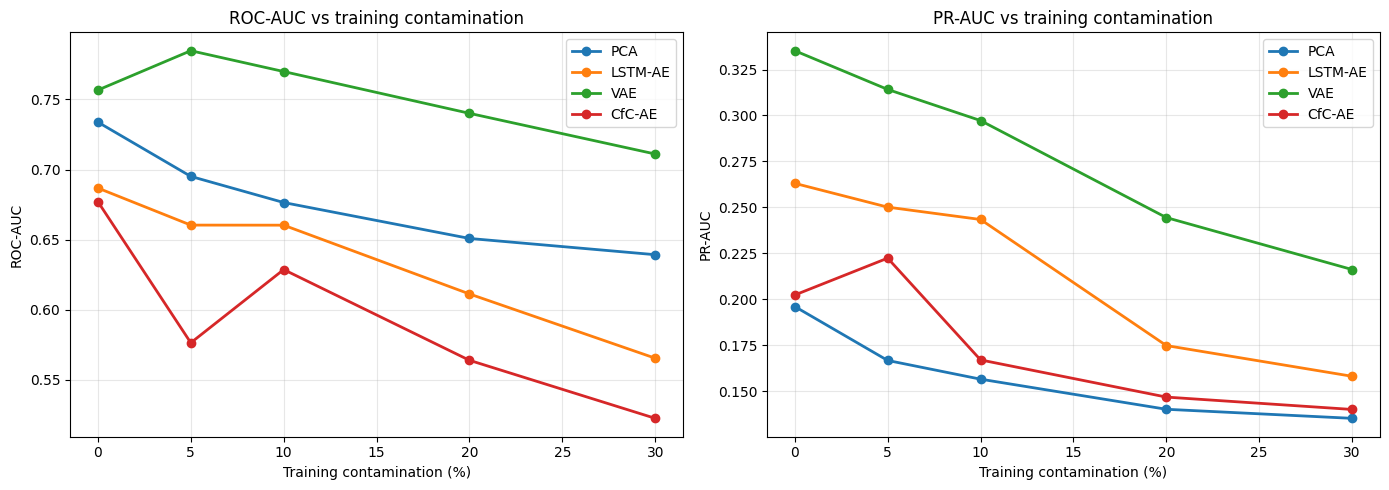

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for metric, ax in zip(["ROC-AUC", "PR-AUC"], axes):
    pivot = results.pivot(index="contamination", columns="model", values=metric)
    for model in ["PCA", "LSTM-AE", "VAE", "CfC-AE"]:
        ax.plot(pivot.index * 100, pivot[model], marker="o", lw=2, label=model)
    ax.set_xlabel("Training contamination (%)")
    ax.set_ylabel(metric)
    ax.set_title(f"{metric} vs training contamination")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Discussion

The degradation curves give a clear robustness ranking — and the VAE stands out.

- **The VAE is by far the most robust.** Its ROC-AUC barely moves from 0% to 30% contamination (0.757 → 0.711, about −0.05), and it is the best model at *every* level. The KL term of the ELBO regularizes the latent space toward the prior, which limits the VAE's ability to memorize the injected anomalies: they stay poorly reconstructed and keep standing out.
- **CfC-AE is the least robust**, dropping the most and heading toward chance (0.677 → 0.522). LSTM-AE and PCA degrade in between.
- **Robustness ranking** (ROC-AUC drop from 0% to 30%): VAE (−0.05) < PCA (−0.10) < LSTM-AE (−0.12) < CfC-AE (−0.16).
- A model that memorizes the training distribution degrades faster, because the injected anomalies get learned as "normal" and stop standing out. The VAE's probabilistic regularization is an implicit defense against this.
- **Note on the baseline:** this analysis uses a fixed 8000-beat training subsample, so the 0% level is *not* identical to notebook 07 (which trains on all ~45.8k DS1 normals). The VAE in particular scores higher here, consistent with the earlier finding that it does not benefit from more training data. The contamination *trend* is the point, and it is internally consistent across levels.
- **Takeaway:** there is no single winner. On clean, full data the models are comparable and PCA is competitive (notebook 07); under training contamination the probabilistic VAE is clearly the most robust. The right choice depends on whether clean-data accuracy or robustness to a dirty training set matters more.